In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.30MB/s]


## Loading the MNIST Dataset

The MNIST dataset consists of handwritten digit images.

Dataset details:

- **60,000 training images**
- **10,000 test images**
- Image size: **28 × 28 pixels**
- Grayscale images representing digits from **0 to 9**

Each image is converted into a **tensor** using the transformation:


The dataset is loaded using PyTorch's `DataLoader`, which enables:

- Efficient batch processing
- Shuffling of training data
- Faster iteration during training

Batch size used: **128 images per batch**.

In [3]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z

    def decode(self, z):
        h = self.relu(self.fc2(z))
        x_recon = self.sigmoid(self.fc3(h))
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

## Variational Autoencoder Architecture

A Variational Autoencoder consists of three main components:

1. **Encoder**
2. **Reparameterization Trick**
3. **Decoder**

Unlike traditional autoencoders, VAEs learn a **probabilistic latent representation** of the input data.

### Encoder

The encoder compresses the input image into a lower dimensional latent representation.

The MNIST image is first flattened:

28 × 28 = **784 input features**

The encoder network performs the following transformation:

784 → 400 → latent parameters

Instead of producing a single vector, the encoder outputs two vectors:

- **Mean (μ)**  
- **Log Variance (log(σ²))**

These parameters define a **Gaussian distribution in latent space**.

### Reparameterization Trick

To generate a latent vector from the learned distribution, we sample from the Gaussian distribution defined by μ and σ.

However, direct sampling prevents gradient backpropagation.

To solve this, the **reparameterization trick** is used:

z = μ + ε × σ

where:

- ε ~ N(0,1) (random noise)
- σ = exp(0.5 × logvar)

This allows gradients to flow through the network during training.

### Decoder

The decoder reconstructs the original image from the sampled latent vector.

The transformation performed by the decoder is:

latent vector → hidden layer → reconstructed image

The final activation function used is **Sigmoid**, which ensures that the output pixel values lie between **0 and 1**, matching the MNIST input image range.

In [4]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

model

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

## Model Initialization

The Variational Autoencoder model is initialized and moved to the selected device (CPU or GPU).

The optimizer used is **Adam**, which is widely used for training deep learning models due to its adaptive learning rate properties.

Learning rate used: **0.001**

Adam optimizer helps achieve faster convergence compared to traditional gradient descent methods.

In [5]:
def vae_loss(recon_x, x, mu, logvar):

    # Reconstruction loss
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    # KL Divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss, recon_loss, kl_loss

## VAE Loss Function

The loss function of a Variational Autoencoder consists of two components:

1. Reconstruction Loss
2. KL Divergence Loss

### Reconstruction Loss

Reconstruction loss measures how well the decoder reconstructs the original image.

Binary Cross Entropy (BCE) is used because pixel values range between 0 and 1.

The loss compares:

Original Image vs Reconstructed Image

Lower reconstruction loss indicates better reconstruction quality.

### KL Divergence Loss

KL Divergence regularizes the latent space by forcing the learned distribution to be close to a standard normal distribution.

The formula for KL divergence is:

KL = -0.5 × Σ (1 + log(σ²) − μ² − σ²)

This encourages the latent space to be smooth and continuous, allowing the model to generate meaningful new samples.

### Total VAE Loss

The total loss used to train the model is:

Total Loss = Reconstruction Loss + KL Divergence Loss

Reconstruction loss ensures accurate image reconstruction, while KL divergence ensures that the latent space follows a structured distribution.

In [10]:
epochs = 20

for epoch in range(epochs):

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for data, _ in train_loader:

        data = data.view(-1, 784).to(device)

        optimizer.zero_grad()

        # Forward pass
        recon_batch, mu, logvar = model(data)

        # Loss
        loss, recon_loss, kl_loss = vae_loss(
            recon_batch, data, mu, logvar
        )

        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}",
        f"Total Loss: {total_loss:.2f}",
        f"Reconstruction Loss: {total_recon:.2f}",
        f"KL Loss: {total_kl:.2f}"
    )

Epoch 1/20 Total Loss: 6351499.41 Reconstruction Loss: 4826762.60 KL Loss: 1524736.80
Epoch 2/20 Total Loss: 6332281.31 Reconstruction Loss: 4805787.61 KL Loss: 1526493.69
Epoch 3/20 Total Loss: 6316854.62 Reconstruction Loss: 4787711.87 KL Loss: 1529142.76
Epoch 4/20 Total Loss: 6301949.14 Reconstruction Loss: 4771879.10 KL Loss: 1530070.04
Epoch 5/20 Total Loss: 6287795.62 Reconstruction Loss: 4755218.14 KL Loss: 1532577.47
Epoch 6/20 Total Loss: 6276125.60 Reconstruction Loss: 4744308.72 KL Loss: 1531816.87
Epoch 7/20 Total Loss: 6263622.86 Reconstruction Loss: 4730574.76 KL Loss: 1533048.09
Epoch 8/20 Total Loss: 6255456.80 Reconstruction Loss: 4722496.35 KL Loss: 1532960.45
Epoch 9/20 Total Loss: 6247121.34 Reconstruction Loss: 4712110.77 KL Loss: 1535010.57
Epoch 10/20 Total Loss: 6237309.95 Reconstruction Loss: 4703739.47 KL Loss: 1533570.47
Epoch 11/20 Total Loss: 6228750.20 Reconstruction Loss: 4693831.68 KL Loss: 1534918.52
Epoch 12/20 Total Loss: 6218611.65 Reconstruction Lo

## Interpretation of Training Loss

Training results:

Epoch 1 Total Loss: 6351499  
Epoch 10 Total Loss: 6237309  
Epoch 20 Total Loss: 6172591

Observations:

- The **total loss decreases gradually over epochs**, indicating that the model is learning.
- **Reconstruction loss decreases steadily**, meaning the decoder is improving at reconstructing digits.
- **KL divergence remains relatively stable**, indicating that the latent distribution is being regularized properly.

The loss values appear large because the loss is summed across:

- All pixels (784 per image)
- All images in each batch
- All batches in an epoch

Thus large values are expected in VAE training.

In [11]:
model.eval()

data, _ = next(iter(test_loader))
data = data.view(-1, 784).to(device)

with torch.no_grad():
    recon, _, _ = model(data)

data = data.view(-1, 1, 28, 28)
recon = recon.view(-1, 1, 28, 28)

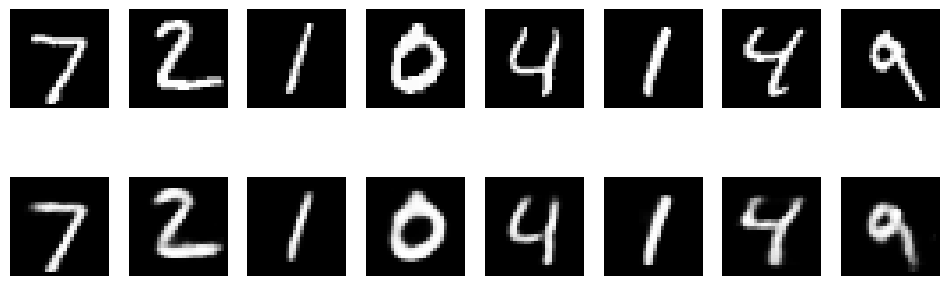

In [12]:
n = 8

plt.figure(figsize=(12,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(data[i][0].cpu(), cmap='gray')
    plt.axis('off')

    # Reconstruction
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(recon[i][0].cpu(), cmap='gray')
    plt.axis('off')

plt.show()

## Reconstruction Results

The visualization shows two rows of images:

Top Row:
Original MNIST digits.

Bottom Row:
Reconstructed digits produced by the VAE.

Observations:

- The reconstructed digits closely resemble the original digits.
- Some slight blurring is visible, which is typical for VAEs.

This occurs because VAEs generate probabilistic reconstructions rather than exact copies of the input.

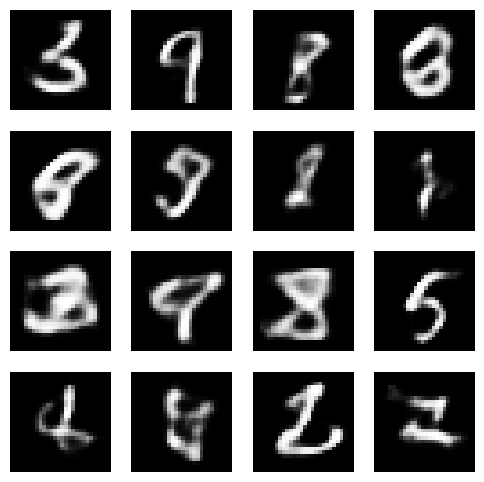

In [13]:
with torch.no_grad():

    z = torch.randn(16, 20).to(device)
    generated = model.decode(z)

generated = generated.view(-1,1,28,28)

plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated[i][0].cpu(), cmap='gray')
    plt.axis('off')

plt.show()

## Generating New Digits

After training, the decoder can generate completely new digits.

Random latent vectors are sampled from a standard normal distribution:

z ~ N(0,1)

These latent vectors are passed through the decoder to generate new images.

The generated images demonstrate that the VAE has successfully learned a structured latent representation of handwritten digits.

## Conclusion

In this experiment, a Variational Autoencoder was successfully implemented using PyTorch on the MNIST dataset.

Key outcomes:

- The encoder successfully maps images to latent space parameters (μ and log(σ²)).
- The reparameterization trick enables gradient-based learning.
- The decoder reconstructs images from latent vectors.
- The model learns meaningful latent representations of handwritten digits.
- The trained VAE can both reconstruct existing images and generate new digit samples.

The decreasing training loss and visually accurate reconstructions confirm that the model has learned useful representations of the MNIST dataset.